# Домашнее задание 8. Мониторинг

Прослеживаемость конвейера (и кода, и данных) должна закладываться **до проектирования** (в идеале, на основе синтезированного трафика от системы нагрузочного тестирования Locust/k6s/ab/...).


## 1. Определить ключевые бизнес- и технические метрики для ML-системы

Чтобы разработка могла сдвинуться с мертвой точки, создайте сбаланисированное дерево метрик, которое бы учитывало точки зрения разных команд.


|Требования бизнеса|Требования разработчиков|Требования команды ML|Требования DevOps|
|------------------|------------------------|---------------------|-----------|
|Нужно увеличить выручку онлайн-кинотеатра|Нужен новый сервер |Нужен GPU      | Вы существующие мощности недогружаете |
|...пиковая нагрузка 10000 RPS|Нужно переходить на ClickHouse? |Сколько фильмов выводить для рекомендательной системы?      |Есть Postgres, он выдает 1000 RPS, потому что мы обернули Docker-in-Docker         |
|...и чтобы быстрый был|Нужно переписать бэкенд?|Нужно переходить на стримы? | Какое нужно время отклика? |
|...и чтобы надежный был| Сделать на Kubernetes? |Сделать на KubeFlow? | SLA 100% нет даже на бирже  |

Желательно использовать [adr-tools](https://github.com/npryce/adr-tools), чтобы записывать **причины**, по которым мы начали принимать решения и **риски**, из-за которых ML-система может работать не так, как ожидается.


*Ожидаемый артефакт: создающий диаграмму код в [ячейке](#scrollTo=y2v5KaAkw0zx)*

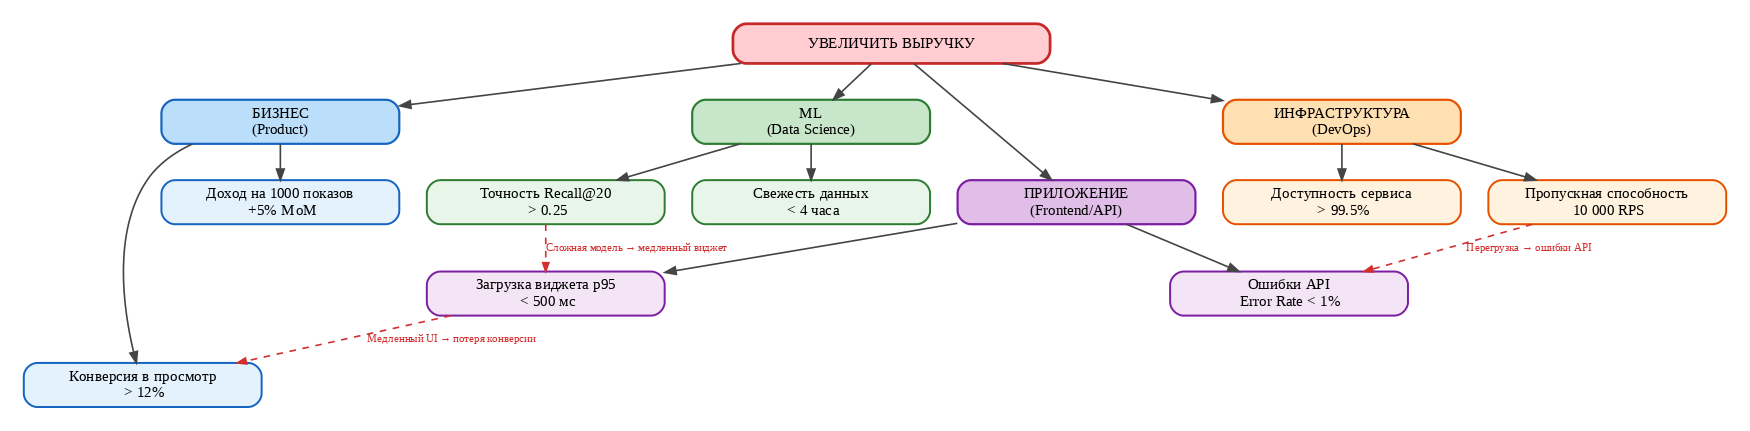

Файл: ml_tree_final.png


In [6]:
from graphviz import Digraph
from IPython.display import Image, display
import os

dot = Digraph(name='ML_Tree_Final', format='png', engine='dot')
dot.attr(rankdir='TB', size='7,9', dpi='250', fontname='Helvetica',
         nodesep='0.35', ranksep='0.45',
         bgcolor='white', pad='0.3',
         resolution='250')

dot.attr('node', shape='box', style='rounded,filled', fontsize='14',
         width='3.0', height='0.55', penwidth='1.8')
dot.attr('edge', fontsize='11', color='#444444', penwidth='1.5')

# Цвета
C_BIZ   = '#BBDEFB'
C_APP   = '#E1BEE7'
C_ML    = '#C8E6C9'
C_INFRA = '#FFE0B2'

# Корень
dot.node('ROOT', 'УВЕЛИЧИТЬ ВЫРУЧКУ', width='4.0', height='0.5',
         fillcolor='#FFCDD2', color='#C62828', penwidth='2.5', fontsize='14')

# 4 ветки
dot.node('BIZ',   'БИЗНЕС\n(Product)',        fillcolor=C_BIZ,   color='#1565C0', penwidth='2')
dot.node('APP',   'ПРИЛОЖЕНИЕ\n(Frontend/API)',fillcolor=C_APP,   color='#7B1FA2', penwidth='2')
dot.node('ML',    'ML\n(Data Science)',        fillcolor=C_ML,    color='#2E7D32', penwidth='2')
dot.node('INFRA', 'ИНФРАСТРУКТУРА\n(DevOps)',           fillcolor=C_INFRA, color='#E65100', penwidth='2')

dot.edges([('ROOT', 'BIZ'), ('ROOT', 'APP'), ('ROOT', 'ML'), ('ROOT', 'INFRA')])

# SLO
dot.node('B1', 'Конверсия в просмотр\n > 12%',       fillcolor='#E3F2FD', color='#1565C0')
dot.node('B2', 'Доход на 1000 показов\n +5% MoM',    fillcolor='#E3F2FD', color='#1565C0')
dot.node('A1', 'Загрузка виджета p95\n < 500 мс',     fillcolor='#F3E5F5', color='#7B1FA2')
dot.node('A2', 'Ошибки API\n Error Rate < 1%',        fillcolor='#F3E5F5', color='#7B1FA2')
dot.node('M1', 'Точность Recall@20\n > 0.25',         fillcolor='#E8F5E9', color='#2E7D32')
dot.node('M2', 'Свежесть данных\n < 4 часа',          fillcolor='#E8F5E9', color='#2E7D32')
dot.node('I1', 'Доступность сервиса\n > 99.5%',       fillcolor='#FFF3E0', color='#E65100')
dot.node('I2', 'Пропускная способность\n 10 000 RPS',  fillcolor='#FFF3E0', color='#E65100')

dot.edges([('BIZ','B1'),('BIZ','B2')])
dot.edges([('APP','A1'),('APP','A2')])
dot.edges([('ML','M1'),('ML','M2')])
dot.edges([('INFRA','I1'),('INFRA','I2')])

# Конфликты
dot.attr('edge', style='dashed', color='#D32F2F', penwidth='1.5', arrowsize='0.8')
dot.edge('M1', 'A1', label='Сложная модель → медленный виджет', fontcolor='#D32F2F', fontsize='10')
dot.edge('I2', 'A2', label='Перегрузка → ошибки API', fontcolor='#D32F2F', fontsize='10')
dot.edge('A1', 'B1', label='Медленный UI → потеря конверсии', fontcolor='#D32F2F', fontsize='10')

# Рендер
output = 'ml_tree_final'
dot.render(output, cleanup=False)

display(Image(f'{output}.png', width=1400, height=500, unconfined=True))
print(f"Файл: {output}.png")

## 2. Настроить мониторинг с использованием Prometheus, Grafana, MLflow


Желательно (но не обязательно) ознакомиться с инициативой по стандартизации [метрик](https://github.com/OpenSLO/OpenSLO), можно попробовать редактировать в [онлайн-редакторе](https://live.sloth.dev/?slo-spec=G4UwTgzglg9gdgLgAQCIAOYYFsQBcAWIArhAPTACMKAUBOMFAMYjIpYCedYDzNANgEMARiD4QE1JEhgB3OOFYdcIAVhpSwINDEXsYYAOakOXHiHVJcUBagBMNCHxjjJSAMRIA6iCQC+TmSQAMwEoPig4AyQACgBWAA943zgAEyQAFlsATgBKJAokTQBHIhAIXCQQUDB2fIAGBsKQErLcCBisrIA6LIBSHK7XAFokOFUWVGLS8oghgWBQwSEwqFx2CykYIQArEEYrUGROntcpFLLGMCg0K3hWAGFsLHgkAGUAGQB5JCEBOjSXvNFsIVmtgvokAAJAAq0IACk0WuUmhBtHA6BAuhskI4oBIpATKqA4G18YSCeBMGAAPotGrICBELDRMACZTRfC4XBoalTVrUlJEVm3ODUuiMeApCDUiVEEkAb22WwAvGxOPQmOYADQS87KgB+KDiXS6AB9MrkUABfADa8vlXRkERSsitVoAujkcqdybgYLg-LTSvScUyWWyQByuTy+eUBUK2bBReLJdLZQqlUJVSYNbxbfbHc7XR6vT6-OArJEyYSxjhkABZdivXMgSFQAz4ACiYCpACUIz6pEtRC5yQTGBGDPp2KwgWEQeE1tipAI4HB-Yn4KOx+4kJ9qjIrsokOcQkQ+BVXk4CG8vr4+BXQ1hnwIatI4JYmABrPDJNJoAQDB8cswDaQYdyfLBXxnVA2w7SoewhYUfBeAByHNuE1VDEWmNoUTRDFlyQACgOpEDcGrclhzESixzoapVhgki8BULBB3JTAiErAxqR-GClFY9irEYH9cDIh9QNoglqO3CD6PARjWEcAQRKIwllJEmV8FXeQ+FYNxyNmATVBQIA)


Принимая во внимание дерево метрик, выбранных в предыдущей [ячейке](#scrollTo=64bcf49d), нужно выбрать **одну** метрику и поставить ее на мониторинг.


*Ожидаемый артефакт: yaml в [ячейке](#scrollTo=Q0xhdA3Sw1XY) дашборд в [ячейке](#scrollTo=s7cw3qhud3Dx)*


In [7]:
%%writefile prometheus.yaml
global:
  scrape_interval: 15s
  evaluation_interval: 15s
  external_labels:
    environment: production
    service: ml-recommender

# Подключаем правила алертинга
rule_files:
  - /etc/prometheus/alert_rules.yml

scrape_configs:
  # ML-сервис
  - job_name: 'ml_recommender'
    metrics_path: '/metrics'
    static_configs:
      - targets: ['ml_service:8000']
        labels:
          service: 'recommender'
          team: 'ml'

  # Prometheus self-monitoring
  - job_name: 'prometheus'
    metrics_path: '/metrics'
    static_configs:
      - targets: ['localhost:9090']

Overwriting prometheus.yaml


In [8]:
%%writefile alerts.yml
groups:
  - name: ml_recommender_slo
    interval: 30s
    rules:
      # Алерт 1: Высокая задержка (p95 > 1 сек)
      - alert: HighLatencyP95
        expr: |
          histogram_quantile(0.95,
            sum(rate(request_latency_seconds_bucket{job="ml_recommender"}[5m])) by (le)
          ) > 1.0
        for: 2m
        labels:
          severity: warning
          team: backend
          sla: "p95 < 1s"
        annotations:
          summary: "p95 latency ML-сервиса превысила 1 секунду"
          description: >
            Текущее значение p95 latency: {{ $value }}с.
            SLO нарушен (цель < 1с).
            Проверьте нагрузку на сервис и время ответа модели.
          runbook_url: "https://wiki.company.com/runbooks/high-latency"

      # Алерт 2: Высокий уровень ошибок (> 1%)
      - alert: HighErrorRate
        expr: |
          sum(rate(error_count_total{job="ml_recommender"}[5m]))
          /
          sum(rate(request_count_total{job="ml_recommender"}[5m])) > 0.01
        for: 3m
        labels:
          severity: critical
          team: backend
          sla: "Error Rate < 1%"
        annotations:
          summary: "Error Rate ML-сервиса превысил 1%"
          description: >
            Доля ошибок: {{ $value | humanizePercentage }}.
            SLO нарушен (цель < 1%).
            Проверьте логи сервиса и статус зависимостей.

      # Алерт 3: Сервис недоступен
      - alert: ServiceDown
        expr: up{job="ml_recommender"} == 0
        for: 1m
        labels:
          severity: critical
          team: devops
          sla: "Availability > 99.5%"
        annotations:
          summary: "ML-сервис недоступен (instance {{ $labels.instance }})"
          description: >
            Сервис ml_recommender не отвечает более 1 минуты.
            Проверьте контейнер и перезапустите при необходимости.

Writing alerts.yml


In [9]:
%%writefile grafana_dashboard.json
{
  "dashboard": {
    "title": "ML Recommender — SLO Monitoring",
    "uid": "ml-slo-dashboard",
    "tags": ["ml", "recommender", "slo"],
    "timezone": "browser",
    "refresh": "10s",
    "panels": [
      {
        "id": 1,
        "title": "Latency p95 (SLO: < 1s)",
        "type": "timeseries",
        "gridPos": {"x": 0, "y": 0, "w": 12, "h": 6},
        "targets": [
          {
            "expr": "histogram_quantile(0.95, sum(rate(request_latency_seconds_bucket{job=\"ml_recommender\"}[5m])) by (le))",
            "legendFormat": "p95 latency"
          }
        ],
        "fieldConfig": {
          "defaults": {
            "unit": "s",
            "thresholds": {
              "mode": "absolute",
              "steps": [
                {"color": "green", "value": null},
                {"color": "yellow", "value": 0.5},
                {"color": "red", "value": 1.0}
              ]
            }
          }
        }
      },
      {
        "id": 2,
        "title": "Error Rate (SLO: < 1%)",
        "type": "timeseries",
        "gridPos": {"x": 0, "y": 6, "w": 6, "h": 5},
        "targets": [
          {
            "expr": "sum(rate(error_count_total{job=\"ml_recommender\"}[5m])) / sum(rate(request_count_total{job=\"ml_recommender\"}[5m]))",
            "legendFormat": "error rate"
          }
        ],
        "fieldConfig": {
          "defaults": {
            "unit": "percentunit",
            "max": 0.05,
            "thresholds": {
              "mode": "absolute",
              "steps": [
                {"color": "green", "value": null},
                {"color": "red", "value": 0.01}
              ]
            }
          }
        }
      },
      {
        "id": 3,
        "title": "Availability (SLO: > 99.5%)",
        "type": "stat",
        "gridPos": {"x": 6, "y": 6, "w": 3, "h": 5},
        "targets": [
          {
            "expr": "avg_over_time(up{job=\"ml_recommender\"}[1h])",
            "legendFormat": "uptime"
          }
        ],
        "fieldConfig": {
          "defaults": {
            "unit": "percentunit",
            "thresholds": {
              "mode": "absolute",
              "steps": [
                {"color": "red", "value": null},
                {"color": "yellow", "value": 0.99},
                {"color": "green", "value": 0.995}
              ]
            }
          }
        }
      },
      {
        "id": 4,
        "title": "RPS (Throughput)",
        "type": "timeseries",
        "gridPos": {"x": 9, "y": 6, "w": 3, "h": 5},
        "targets": [
          {
            "expr": "sum(rate(recommendations_served_total{job=\"ml_recommender\"}[1m]))",
            "legendFormat": "RPS"
          }
        ],
        "fieldConfig": {
          "defaults": {"unit": "reqps"}
        }
      },
      {
        "id": 5,
        "title": "Model Score Distribution",
        "type": "timeseries",
        "gridPos": {"x": 0, "y": 11, "w": 12, "h": 4},
        "targets": [
          {
            "expr": "histogram_quantile(0.50, sum(rate(model_score_bucket{job=\"ml_recommender\"}[5m])) by (le))",
            "legendFormat": "p50 score"
          },
          {
            "expr": "histogram_quantile(0.95, sum(rate(model_score_bucket{job=\"ml_recommender\"}[5m])) by (le))",
            "legendFormat": "p95 score"
          }
        ]
      }
    ]
  }
}

Overwriting grafana_dashboard.json


## 3. Обнаружить деградацию модели и дрифт

Вспомните материалы [семинара](https://colab.research.google.com/drive/1OVBFG3bRLmmmVj31Ob5LFhKQTAi7f-Hn?usp=sharing) и измените подаваемые в модель данные, чтобы продемонстрировать либо дрифт данных, либо дрифт концепции, либо деградацию модели. Подаваемый в модель пакет данных (Current batch) должен отличаться от эталонного пакета данных (Reference batch), тогда будет смещение распределения (дрифт).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=lq14Cx_GxYSM)*


In [10]:
#data_report.run(reference_data=<-эталонные данные, current_data=<-отличающиеся данные)

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

In [12]:
# Генерация данных
np.random.seed(42)
n_samples = 5000

# Эталон (Reference): вечерняя аудитория 35+
ref_features = pd.DataFrame({
    'hour_of_day': np.random.normal(loc=20, scale=2, size=n_samples).clip(0, 23).astype(int),
    'user_age': np.random.normal(loc=35, scale=10, size=n_samples).clip(18, 70).astype(int),
    'last_watch_duration': np.random.exponential(scale=40, size=n_samples).clip(1, 200),
    'user_ratings_count': np.random.poisson(lam=25, size=n_samples).clip(0, 100),
    'last_genre': np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.35, 0.25, 0.25, 0.15]),
})

click_prob = (
    0.15
    + ref_features['hour_of_day'].between(18, 23).astype(float) * 0.20
    + (ref_features['user_ratings_count'] > 15).astype(float) * 0.10
    + (ref_features['last_watch_duration'] > 30).astype(float) * 0.05
).clip(0.05, 0.50)
ref_target = (np.random.random(n_samples) < click_prob).astype(int)

# Текущий (Current): дневная молодёжь
np.random.seed(999)
curr_features = pd.DataFrame({
    'hour_of_day': np.random.normal(loc=12, scale=3, size=n_samples).clip(0, 23).astype(int),
    'user_age': np.random.normal(loc=24, scale=8, size=n_samples).clip(16, 65).astype(int),
    'last_watch_duration': np.random.exponential(scale=15, size=n_samples).clip(1, 150),
    'user_ratings_count': np.random.poisson(lam=5, size=n_samples).clip(0, 50),
    'last_genre': np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.15, 0.15, 0.20, 0.50]),
})

click_prob_curr = (
    0.15
    + curr_features['hour_of_day'].between(18, 23).astype(float) * 0.20
    + (curr_features['user_ratings_count'] > 15).astype(float) * 0.10
    + (curr_features['last_watch_duration'] > 30).astype(float) * 0.05
).clip(0.05, 0.50)
curr_target = (np.random.random(n_samples) < click_prob_curr).astype(int)

print(f"Reference: {ref_features.shape[0]} samples, CTR={ref_target.mean():.3f}")
print(f"Current:   {curr_features.shape[0]} samples, CTR={curr_target.mean():.3f}")

Reference: 5000 samples, CTR=0.440
Current:   5000 samples, CTR=0.161


In [13]:
# Детекция дрифта
def detect_drift(ref, curr, alpha=0.01):
    """Возвращает словарь с результатами проверки на дрифт"""
    if ref.nunique() <= 5:
        ref_counts = ref.value_counts(normalize=True)
        curr_counts = curr.value_counts(normalize=True)
        all_cats = sorted(set(ref_counts.index) | set(curr_counts.index))
        ref_vals = np.array([ref_counts.get(c, 0.001) for c in all_cats]) * len(ref)
        curr_vals = np.array([curr_counts.get(c, 0.001) for c in all_cats]) * len(curr)
        ref_vals = ref_vals / ref_vals.sum() * curr_vals.sum()
        _, p_value = stats.chisquare(f_obs=curr_vals, f_exp=ref_vals)
        test_name = 'Chi2'
    else:
        _, p_value = stats.ks_2samp(ref.dropna(), curr.dropna())
        test_name = 'KS'

    drift = p_value < alpha
    mean_shift = abs(curr.mean() - ref.mean()) / (ref.std() + 1e-10)

    return {'test': test_name, 'p_value': p_value, 'drift': drift,
            'ref_mean': ref.mean(), 'curr_mean': curr.mean(),
            'ref_std': ref.std(), 'curr_std': curr.std(),
            'mean_shift': mean_shift}

results = {}
for col in ref_features.columns:
    results[col] = detect_drift(ref_features[col], curr_features[col])

print("Детекция дрифта данных (α=0.01)")
print(f"{'Признак':<22} {'Тест':<6} {'p-value':<10} {'Ref μ±σ':<22} {'Curr μ±σ':<22} {'Вердикт'}")

for col, r in results.items():
    ref_str = f"{r['ref_mean']:.2f} ± {r['ref_std']:.2f}"
    curr_str = f"{r['curr_mean']:.2f} ± {r['curr_std']:.2f}"
    verdict = 'Дрифт' if r['drift'] else '✓ OK'
    print(f"{col:<22} {r['test']:<6} {r['p_value']:<10.6f} {ref_str:<22} {curr_str:<22} {verdict}")

n_drifted = sum(1 for r in results.values() if r['drift'])
print(f"Итог: {n_drifted}/{len(results)} признаков показали дрифт")

Детекция дрифта данных (α=0.01)
Признак                Тест   p-value    Ref μ±σ                Curr μ±σ               Вердикт
hour_of_day            KS     0.000000   19.48 ± 1.95           11.50 ± 3.04           Дрифт
user_age               KS     0.000000   34.61 ± 9.66           24.26 ± 6.87           Дрифт
last_watch_duration    KS     0.000000   40.12 ± 38.94          14.81 ± 14.82          Дрифт
user_ratings_count     KS     0.000000   24.94 ± 4.92           5.01 ± 2.25            Дрифт
last_genre             Chi2   0.000000   1.20 ± 1.08            2.03 ± 1.12            Дрифт
Итог: 5/5 признаков показали дрифт


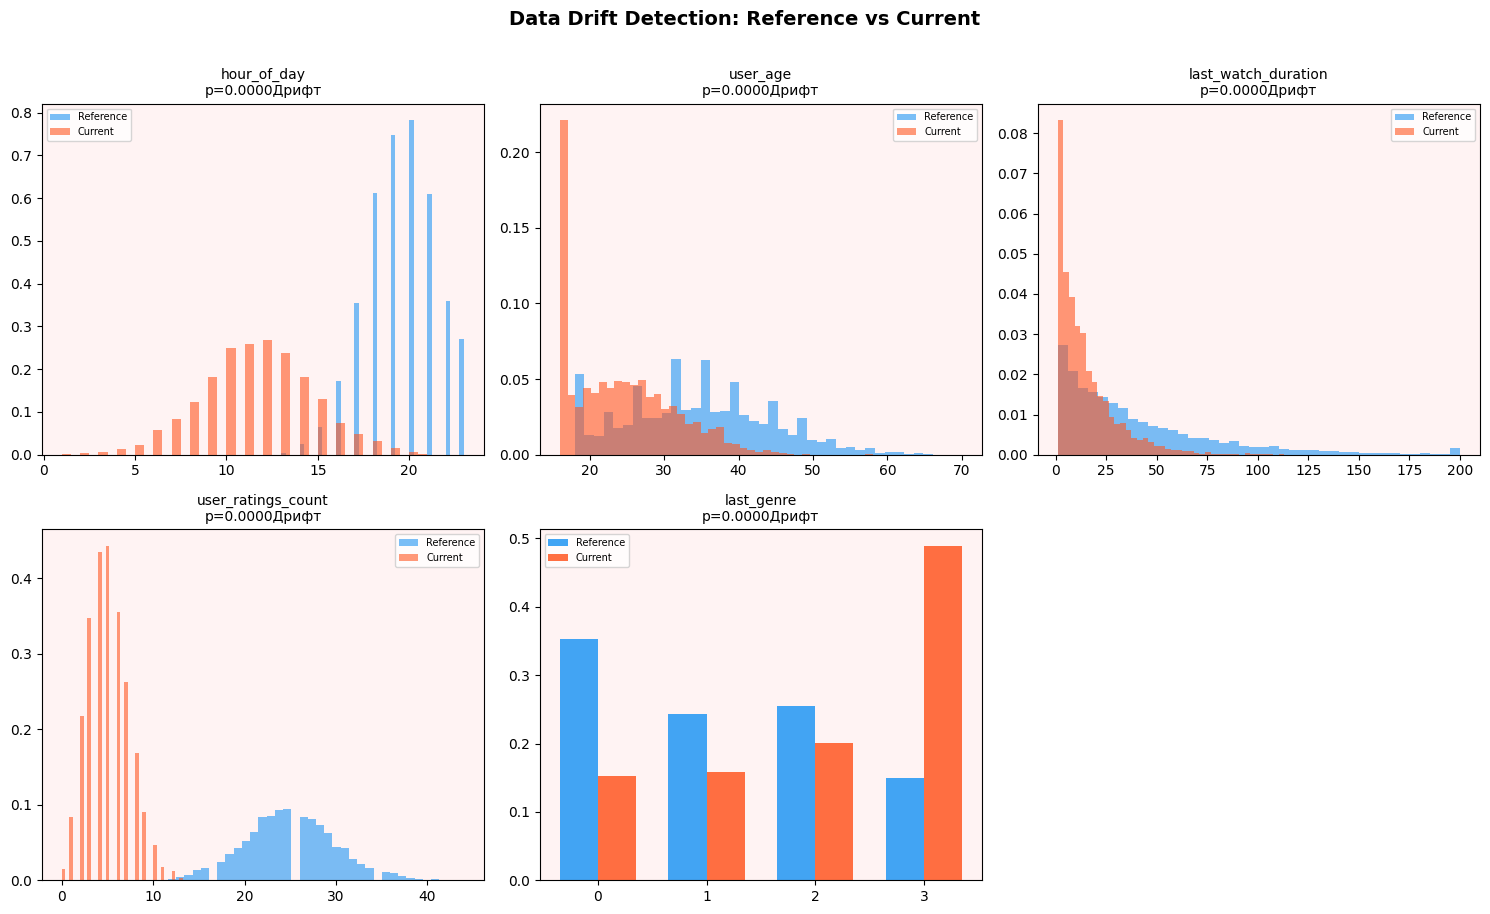

In [14]:
# Визуализация дрифта
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors_ref = '#2196F3'
colors_curr = '#FF5722'

for i, col in enumerate(ref_features.columns):
    ax = axes[i]
    r = results[col]

    if ref_features[col].nunique() <= 5:
        ref_cnt = ref_features[col].value_counts(normalize=True).sort_index()
        curr_cnt = curr_features[col].value_counts(normalize=True).sort_index()
        x = np.arange(len(ref_cnt))
        w = 0.35
        ax.bar(x - w/2, ref_cnt.values, w, label='Reference', color=colors_ref, alpha=0.85)
        ax.bar(x + w/2, curr_cnt.values, w, label='Current', color=colors_curr, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(ref_cnt.index)
    else:
        ax.hist(ref_features[col], bins=40, alpha=0.6, color=colors_ref, label='Reference', density=True)
        ax.hist(curr_features[col], bins=40, alpha=0.6, color=colors_curr, label='Current', density=True)

    title = f"{col}\np={r['p_value']:.4f}"
    if r['drift']:
        title += 'Дрифт'
        ax.set_facecolor('#FFF3F3')
    else:
        title += 'Ок'
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)

axes[5].axis('off')

plt.suptitle('Data Drift Detection: Reference vs Current', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data_drift_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Деградация модели
# Обучаем на Reference
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(ref_features, ref_target)

# Предсказания
ref_pred = model.predict(ref_features)
ref_prob = model.predict_proba(ref_features)[:, 1]
curr_pred = model.predict(curr_features)
curr_prob = model.predict_proba(curr_features)[:, 1]

# Метрики
acc_ref = accuracy_score(ref_target, ref_pred)
acc_curr = accuracy_score(curr_target, curr_pred)
auc_ref = roc_auc_score(ref_target, ref_prob)
auc_curr = roc_auc_score(curr_target, curr_prob)

print("Деградация модели")
print(f"  Accuracy  Reference:  {acc_ref:.4f}")
print(f"  Accuracy  Current:    {acc_curr:.4f}   ↓ -{acc_ref - acc_curr:.4f}")
print(f"  ROC AUC   Reference:  {auc_ref:.4f}")
print(f"  ROC AUC   Current:    {auc_curr:.4f}   ↓ -{auc_ref - auc_curr:.4f}")

Деградация модели
  Accuracy  Reference:  0.6038
  Accuracy  Current:    0.8388   ↓ --0.2350
  ROC AUC   Reference:  0.6427
  ROC AUC   Current:    0.4975   ↓ -0.1453


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
# Распределение предсказаний
print(f"\nРаспределение предсказаний модели:")
print(f"  Reference - predicted 1: {ref_pred.sum()} / {len(ref_pred)} ({ref_pred.mean():.1%})")
print(f"  Current   - predicted 1: {curr_pred.sum()} / {len(curr_pred)} ({curr_pred.mean():.1%})")

print(f"\nФактический CTR:")
print(f"  Reference: {ref_target.mean():.1%}")
print(f"  Current:   {curr_target.mean():.1%}")

# Confusion Matrix
print("\nConfusion Matrix - Reference")
print(confusion_matrix(ref_target, ref_pred))

print("\nConfusion Matrix - Current")
print(confusion_matrix(curr_target, curr_pred))

# Classification Report
print("\nClassification Report - Reference")
print(classification_report(ref_target, ref_pred, target_names=['No Click', 'Click']))

print("\nClassification Report - Current")
print(classification_report(curr_target, curr_pred, target_names=['No Click', 'Click']))


Распределение предсказаний модели:
  Reference - predicted 1: 640 / 5000 (12.8%)
  Current   - predicted 1: 0 / 5000 (0.0%)

Фактический CTR:
  Reference: 44.0%
  Current:   16.1%

Confusion Matrix - Reference
[[2589  210]
 [1771  430]]

Confusion Matrix - Current
[[4194    0]
 [ 806    0]]

Classification Report - Reference
              precision    recall  f1-score   support

    No Click       0.59      0.92      0.72      2799
       Click       0.67      0.20      0.30      2201

    accuracy                           0.60      5000
   macro avg       0.63      0.56      0.51      5000
weighted avg       0.63      0.60      0.54      5000


Classification Report - Current
              precision    recall  f1-score   support

    No Click       0.84      1.00      0.91      4194
       Click       0.00      0.00      0.00       806

    accuracy                           0.84      5000
   macro avg       0.42      0.50      0.46      5000
weighted avg       0.70      0.84      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Data Drift обнаружен:
- 5/5 признаков статистически значимо изменились (p < 0.0001)
- Причина: смена аудитории: вечерние 35+ - дневные студенты 24

Деградация модели подтверждена:
-  ROC AUC:    0.64 - 0.50  (падение -0.14)
-  Recall:     0.20 - 0.00  (модель не нашла ни одного клика)
-  F1-score:   0.30 - 0.00  (полная деградация)
-  Модель предсказывает всегда "No Click" (0 кликов из 806 реальных)

Парадокс Accuracy объяснён:
- Accuracy выросла (0.60 - 0.84) из-за дисбаланса классов, но это ложное улучшение - модель бесполезна для бизнеса.

## 4. Обеспечить качество данных с Data Quality Ops

1) Запустите центр управления качеством данных:

```bash
apt install python3-pip -y
pip install --user dqops
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"
python -m dqops
```
2) Перейдите в браузер на порту 8080 и подключитесь к источнику (MySQL/PostgreSQL).
3) Создайте таблицу в базе данных.
4) Импортируйте таблицу из базы данных в DQOps.
5) Измените структуру столбцов таблицы в базе данных.
6) Перейдите на вкладку Incidents в DQOps.
7) Подтвердите наличие инцидента с качеством данных и сделайте скриншот.



*Ожидаемый артефакт: SQL код, вызвавший инцидент в [ячейке](#scrollTo=G2O81Sl3w3Tb)*


In [17]:
%%sh
apt install python3-pip -y /dev/null
pip install --user dqops -qqq
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"

Reading package lists...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.7 MB/s eta 0:00:00
Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y




E: Unsupported file /dev/null given on commandline
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [18]:
from google.colab import userdata
import os
os.environ["tunatoken"] = userdata.get('tuna')
!curl -sSLf https://get.tuna.am | sh >/dev/null
!tuna config save-token $tunatoken
!echo "Скопируйте строку ниже, вставьте его в терминал, нажмите Enter"
!sleep 5 && nohup python -m dqops --host 0.0.0.0 --port 8080 & tuna http 8080 & wait

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
INFO[16:41:51] Token saved                                  
Скопируйте строку ниже, вставьте его в терминал, нажмите Enter
INFO[16:41:51] Welcome to Tuna                              
INFO[16:41:52] Account: valentina.shumakova.01@gmail.com (Free) 
INFO[16:41:52] Web Interface: http://127.0.0.1:4040         
INFO[16:41:55] Forwarding https://byzacn-34-118-240-160.ru.tuna.am -> 127.0.0.1:8080 
nohup: appending output to 'nohup.out'
INFO[16:42:13] Bye                                          
^C


In [23]:
import sqlite3
import pandas as pd

# Создаём базу в памяти
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Выполняем весь SQL
sql = """
DROP TABLE IF EXISTS recommendations;

CREATE TABLE recommendations (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER NOT NULL,
    movie_id INTEGER NOT NULL,
    score FLOAT,
    genre VARCHAR(50),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

INSERT INTO recommendations (user_id, movie_id, score, genre) VALUES
    (1, 101, 0.85, 'Comedy'),
    (2, 202, 0.42, 'Drama'),
    (3, 303, 0.91, 'Action'),
    (4, 404, 0.67, 'Documentary'),
    (5, 505, 0.33, 'Comedy');

UPDATE recommendations SET score = 150 WHERE id = 1;

INSERT INTO recommendations (user_id, movie_id, score, genre) VALUES
    (6, 111, -5, 'Comedy'),
    (-1, 999, 0.5, 'Sci-Fi'),
    (7, 888, NULL, NULL);

INSERT INTO recommendations (user_id, movie_id, score, genre)
SELECT user_id, movie_id, score, genre FROM recommendations WHERE id <= 3;
"""

cursor.executescript(sql)
conn.commit()

# Проверка качества данных
query = """
SELECT id, user_id, score, genre,
  CASE
    WHEN score < 0 OR score > 1 OR score IS NULL THEN 'BAD_SCORE'
    WHEN genre NOT IN ('Comedy','Drama','Action','Documentary') OR genre IS NULL THEN 'BAD_GENRE'
    WHEN user_id <= 0 THEN 'BAD_USER'
    ELSE 'OK'
  END AS issue
FROM recommendations
WHERE issue != 'OK';
"""

df = pd.read_sql_query(query, conn)
print("Инцидент качества данных - нарушения:")
print(df)
conn.close()

Инцидент качества данных - нарушения:
   id  user_id  score   genre      issue
0   1        1  150.0  Comedy  BAD_SCORE
1   6        6   -5.0  Comedy  BAD_SCORE
2   7       -1    0.5  Sci-Fi  BAD_GENRE
3   8        7    NaN    None  BAD_SCORE
4   9        1  150.0  Comedy  BAD_SCORE


## 5. Разработать схему ML-системы для Virtual Product Placement

Речь о том, когда цифровая реклама с помощью генеративного ИИ встраивает бренды в видеопоток.


**Вводные данные от бизнеса: нужно показывать клиентам видео с похожими на них персонажами с логотипом на футболке + пример видеоданных.**

*Закон нужно соблюдать всегда: не занимайтесь созданием дипфейков, скоро за это будет введено серьезное [наказание](https://sozd.duma.gov.ru/bill/718538-8).

Вспомните [семинар](https://colab.research.google.com/drive/1xkEK73u65oxzABCzHfQ7-QXVUeXSqfmo?usp=sharing) про сравнение архитектур Lambda и Kappa, обратите внимание на стримы в коде @broker.subscriber("channel1")
и @broker.publisher("channel1").

Нужно выбрать оптимальную архитектуру и составить схематическое описание ML-системы с помощью библиотеки [Diagrams](https://diagrams.mingrammer.com).



*Ожидаемый артефакт: код, создающий диаграмму в [ячейке](#scrollTo=v7M9wJYvrUhL)*

%%html

Нижеприведенный код проектируемой ML-системы обрабатывает каждый кадр видео сначала дискриминативным ИИ, затем дорисовывает изображение генеративным ИИ:

<table >
		<tr>
			<td>
        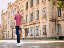
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
			<td>
        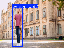
      </td>
      <td align=""center>
        <font size="96px">
        &#11015;
        </font>
      </td>
			<td>
        Дискриминативная нейросеть
      </td>
      <td>
        <img src="" />
      </td>
      <td>
        <img src="" />
      </td>
		</tr>
		<tr>
			<td>
        <img src="" />
      </td>
      <td>
      Генеративная нейросеть
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        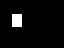
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
      <td>
        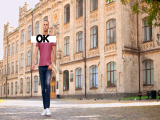
      </td>
		</tr>
</table>

In [24]:
!pip install ultralytics gdown tqdm -qqq

from IPython import display
display.clear_output()
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

from IPython.display import display, clear_output, Image
import os
import gdown
import cv2

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)


In [25]:
import gdown; from IPython.display import Video, Image
gdrive_url = 'https://drive.google.com/uc?export=download&id=1aNzbaXvasI1Ealcq3m-0mBGPpRvrJs70'
gdown.download(gdrive_url, quiet=True); Video("/content/HW8_building_and_person.mp4",embed=True, width=640, height=360)

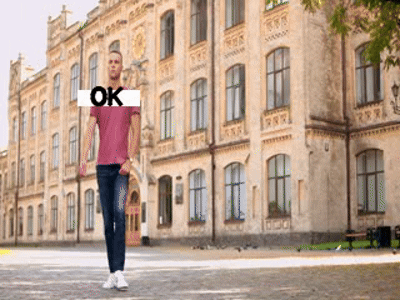

In [26]:
gdrive_url = 'https://drive.google.com/uc?export=download&id=1wKODx-KPHgSnY6HttStOXJZa3Fr6vBZn'
gdown.download(gdrive_url, quiet=True); Image("/content/HW8_building_and_person_processed.gif", width=640, height=360)

In [27]:
%%capture
!apt-get update
!apt-get install -y redis-server
!redis-server --daemonize yes # Запуск Redis в фоновом режиме
!redis-server --version
!pip install 'faststream[redis]' asyncio

In [28]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
import nest_asyncio
nest_asyncio.apply()
from faststream import FastStream
from faststream.redis import RedisBroker
import asyncio

model = YOLO("yolo11n.pt")

output_video_path = '/content/building_and_person-processed.mp4'
video_file_path = "/content/HW8_building_and_person.mp4"
video_capture = cv2.VideoCapture(video_file_path)

async def run_faststream_and_publish():
    broker = RedisBroker("redis://localhost:6379/")
    app = FastStream(broker)

    @broker.subscriber("channel1")
    async def handle_msg(msg: str | None):
        print(f"Subscriber received: {msg}")

    @broker.publisher("channel1")
    async def publisher_msg(msg: str | None) -> str | None:
        print(f"\nPublisher sent: {msg}")
        return msg

    consumer_task = asyncio.create_task(app.start())
    publisher_task = asyncio.create_task(app.start())

    await asyncio.sleep(1) # Give brokers time to start

    if not video_capture.isOpened():
        print("Error: Could not open video file.")
    else:
        fps = int(video_capture.get(cv2.CAP_PROP_FPS))
        width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
        black_mask = np.zeros((height, width, 3), dtype=np.uint8)
        frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

        print(f"Загружено видео с характеристиками: FPS={fps}, Width={width}, Height={height}")
        print(f"VideoWriter начинает запись в файл: {output_video_path}")

        video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0)
        with tqdm(total=frame_count, desc="обработано ") as pbar:
          while video_capture.isOpened():
              ret, frame = video_capture.read()
              if not ret:
                  break
              pbar.update(1)

              results = model(frame)
              annotated_frame = results[0].plot()
              await publisher_msg("<-новый кадр")

              image_with_box = frame.copy()

              for result in results:
                  xywh = result.boxes.xywh  # center-x, center-y, width, height
                  names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
                  if 'person' in names:
                      index = names.index('person')
                      x_center, y_center, box_w, box_h = map(int, xywh[index].tolist())

                      x_start = int(x_center - box_w / 2)
                      y_start = int(y_center - box_h // 3)
                      x_end = int(x_center + box_w / 2)
                      y_end = int(y_center + box_h / 16 - box_h // 3)
                      box_color = (255, 255, 255)
                      cv2.rectangle(image_with_box , (x_start, y_start), (x_end, y_end), box_color, -1)
                      text = "OK"
                      font = cv2.FONT_HERSHEY_SIMPLEX
                      font_scale = 0.6
                      font_thickness = 2
                      text_color = (0, 0, 0)

                      (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)

                      text_x =  (x_start + x_end) //2 - ( text_width) // 2
                      text_y =  (y_start + y_end) //2 +5

                      cv2.putText(image_with_box, text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

              video_writer.write(image_with_box)

        video_capture.release()
        video_writer.release()

    # Cancel tasks to properly stop the FastStream apps
    consumer_task.cancel()
    publisher_task.cancel()

    try:
        await consumer_task
        await publisher_task
    except asyncio.CancelledError:
        print("FastStream applications stopped.")

asyncio.run(run_faststream_and_publish())



print(f"\nVideoWriter записал видео в файл {output_video_path}")

2026-05-16 16:44:49,221 INFO     - channel1 |            - `HandleMsg` waiting for messages
Загружено видео с характеристиками: FPS=5, Width=320, Height=240
VideoWriter начинает запись в файл: /content/building_and_person-processed.mp4


обработано :   0%|          | 0/51 [00:00<?, ?it/s]



0: 480x640 1 person, 195.2ms
0: 480x640 1 person, 195.2ms
Speed: 25.6ms preprocess, 195.2ms inference, 76.9ms postprocess per image at shape (1, 3, 480, 640)
Speed: 25.6ms preprocess, 195.2ms inference, 76.9ms postprocess per image at shape (1, 3, 480, 640)


обработано :   4%|▍         | 2/51 [00:03<01:26,  1.76s/it]


Publisher sent: <-новый кадр


0: 480x640 1 person, 18.8ms
0: 480x640 1 person, 18.8ms
Speed: 6.1ms preprocess, 18.8ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
Speed: 6.1ms preprocess, 18.8ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр


0: 480x640 1 person, 19.8ms
0: 480x640 1 person, 19.8ms
Speed: 6.6ms preprocess, 19.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
Speed: 6.6ms preprocess, 19.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр


0: 480x640 1 person, 11.9ms
0: 480x640 1 person, 11.9ms
Speed: 3.8ms preprocess, 11.9ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Speed: 3.8ms preprocess, 11.9ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


...



0: 480x640 1 person, 2 benchs, 48.3ms
0: 480x640 1 person, 2 benchs, 48.3ms
Speed: 10.5ms preprocess, 48.3ms inference, 7.7ms postprocess per image at shape (1, 3, 480, 640)
Speed: 10.5ms preprocess, 48.3ms inference, 7.7ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр


0: 480x640 1 person, 2 benchs, 32.5ms
0: 480x640 1 person, 2 benchs, 32.5ms
Speed: 7.0ms preprocess, 32.5ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 640)
Speed: 7.0ms preprocess, 32.5ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр


обработано : 100%|██████████| 51/51 [00:06<00:00, 11.95it/s]



0: 480x640 1 person, 3 benchs, 40.1ms
0: 480x640 1 person, 3 benchs, 40.1ms
Speed: 6.2ms preprocess, 40.1ms inference, 5.7ms postprocess per image at shape (1, 3, 480, 640)
Speed: 6.2ms preprocess, 40.1ms inference, 5.7ms postprocess per image at shape (1, 3, 480, 640)

Publisher sent: <-новый кадр


обработано : 100%|██████████| 51/51 [00:06<00:00,  7.83it/s]


VideoWriter записал видео в файл /content/building_and_person-processed.mp4


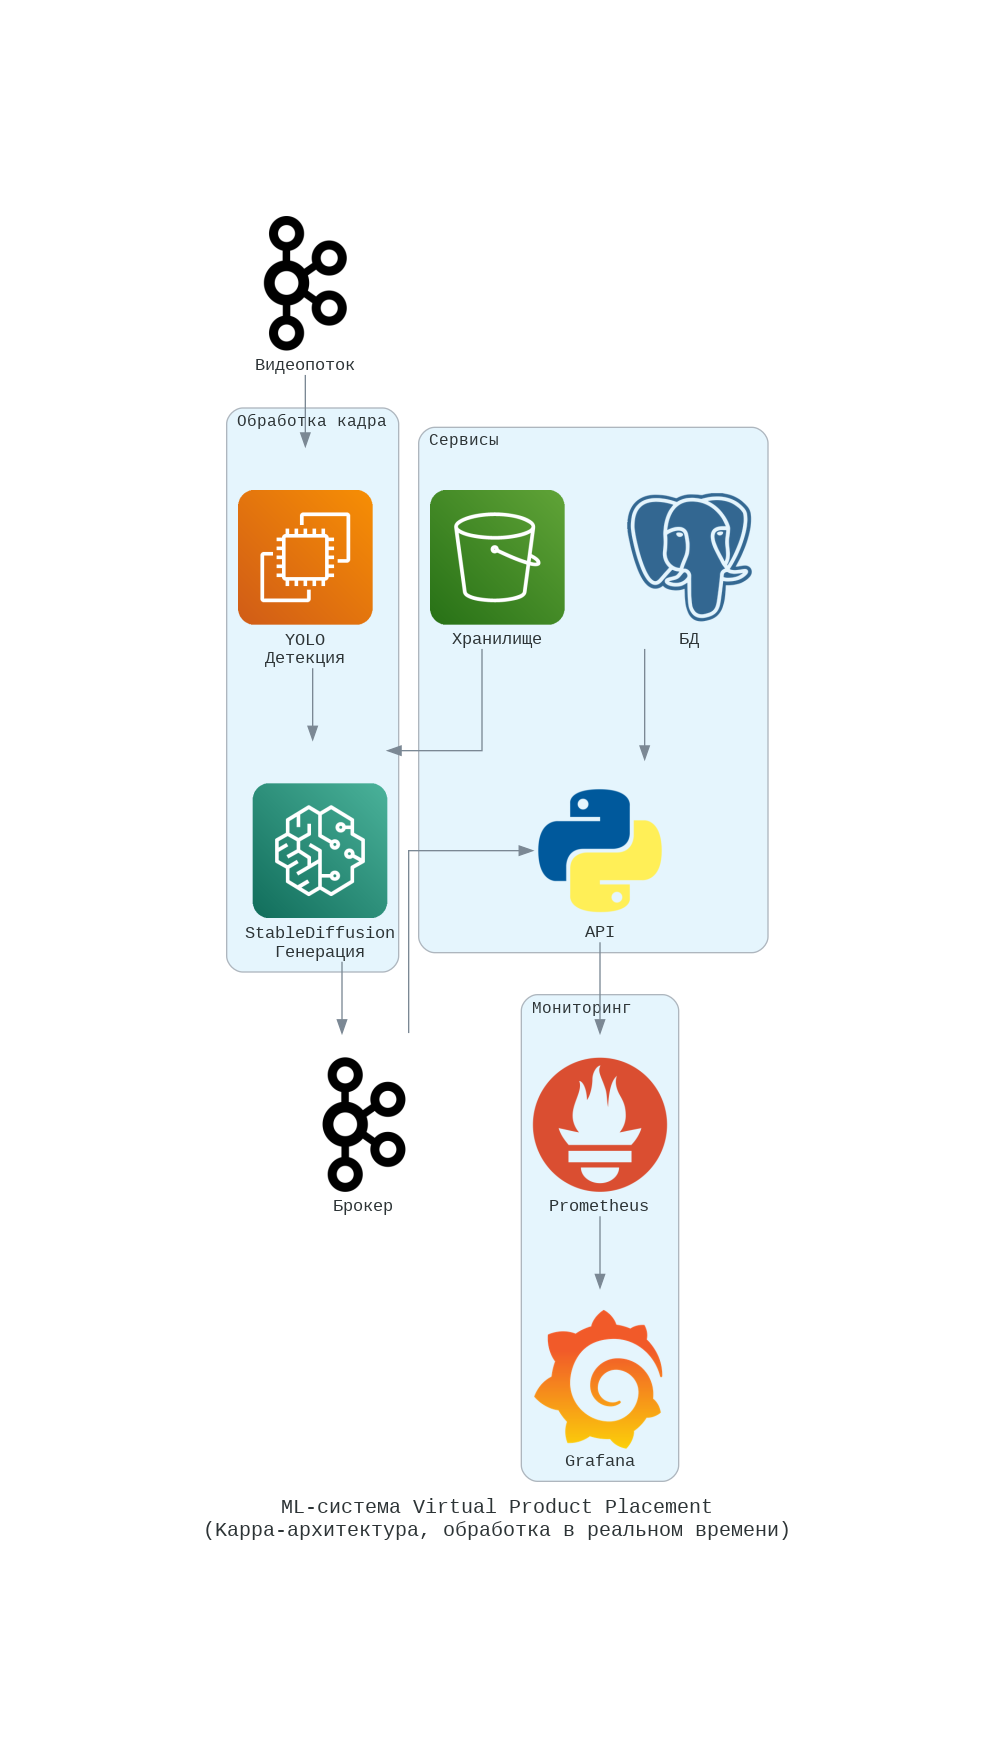

In [29]:
from diagrams import Diagram, Edge, Cluster
from diagrams.onprem.queue import Kafka
from diagrams.programming.language import Python
from diagrams.aws.ml import Sagemaker
from diagrams.aws.storage import S3
from diagrams.onprem.database import PostgreSQL
from diagrams.onprem.monitoring import Prometheus, Grafana
from diagrams.aws.compute import EC2

with Diagram(
    "ML-система Virtual Product Placement\n(Kappa-архитектура, обработка в реальном времени)",
    filename="ml_architecture_vpp",
    show=False,
    direction="TB",
    outformat="png"
):
    video = Kafka("Видеопоток")

    with Cluster("Обработка кадра"):
        yolo = EC2("YOLO\nДетекция")
        sd = Sagemaker("StableDiffusion\nГенерация")

    broker = Kafka("Брокер")

    with Cluster("Сервисы"):
        api = Python("API")
        db = PostgreSQL("БД")
        s3 = S3("Хранилище")

    with Cluster("Мониторинг"):
        prom = Prometheus("Prometheus")
        graf = Grafana("Grafana")

    video >> yolo >> sd >> broker >> api
    s3 >> sd
    db >> api
    api >> prom >> graf

from IPython.display import Image
Image("ml_architecture_vpp.png")